In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [33]:
data_wine = load_wine()
display(type(data_wine))

# print(data_wine.data)
# print(data_wine.target)
X = data_wine.data
Y = data_wine.target

print(X.shape)
print(X.shape[0]*X.shape[1])

# number of classes
print(np.unique(Y))


sklearn.utils._bunch.Bunch

(178, 13)
2314
[0 1 2]


In [44]:
print(data_wine.feature_names)

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [46]:
# Y is discrete we choose Classifier instead of Regressor
print(np.unique(Y))
print(type(np.unique(Y)))

[0 1 2]
<class 'numpy.ndarray'>


In [47]:
print(data_wine.data)

[[1.423e+01 1.710e+00 2.430e+00 ... 1.040e+00 3.920e+00 1.065e+03]
 [1.320e+01 1.780e+00 2.140e+00 ... 1.050e+00 3.400e+00 1.050e+03]
 [1.316e+01 2.360e+00 2.670e+00 ... 1.030e+00 3.170e+00 1.185e+03]
 ...
 [1.327e+01 4.280e+00 2.260e+00 ... 5.900e-01 1.560e+00 8.350e+02]
 [1.317e+01 2.590e+00 2.370e+00 ... 6.000e-01 1.620e+00 8.400e+02]
 [1.413e+01 4.100e+00 2.740e+00 ... 6.100e-01 1.600e+00 5.600e+02]]


In [48]:
print(data_wine.target)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [50]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 55)

In [51]:
depth = [1, 2, 3, 4, 5, 10, 100, 1000]

In [53]:
for d in depth:
    clf = DecisionTreeClassifier(max_depth = d, random_state = 55)
    clf.fit(X_train, Y_train)

    predicted = clf.predict(X_test)
    accuracy  = accuracy_score(Y_test, predicted)
    precision = precision_score(Y_test, predicted, average='macro')
    recall    = recall_score(Y_test, predicted,average='macro')
    f1        = f1_score(Y_test, predicted, average='macro')
    print("depth = ",d)
    print("accuracy : ",accuracy)
    print("precision: ",precision)
    print("recall   : ", recall)
    print("f1       : ", f1)
    print("==========================")

depth =  1
accuracy :  0.6388888888888888
precision:  0.4424242424242424
recall   :  0.6666666666666666
f1       :  0.5307017543859649
depth =  2
accuracy :  0.7777777777777778
precision:  0.8280701754385964
recall   :  0.7856837606837607
f1       :  0.7978971298664392
depth =  3
accuracy :  0.8888888888888888
precision:  0.9133986928104575
recall   :  0.8848290598290598
f1       :  0.8961111111111112
depth =  4
accuracy :  0.8888888888888888
precision:  0.907051282051282
recall   :  0.8848290598290598
f1       :  0.8942376619795974
depth =  5
accuracy :  0.9166666666666666
precision:  0.9326923076923078
recall   :  0.9104700854700855
f1       :  0.919878687620623
depth =  10
accuracy :  0.8888888888888888
precision:  0.8869047619047619
recall   :  0.8882478632478632
f1       :  0.8868135376756067
depth =  100
accuracy :  0.8888888888888888
precision:  0.8869047619047619
recall   :  0.8882478632478632
f1       :  0.8868135376756067
depth =  1000
accuracy :  0.8888888888888888
precision

C:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


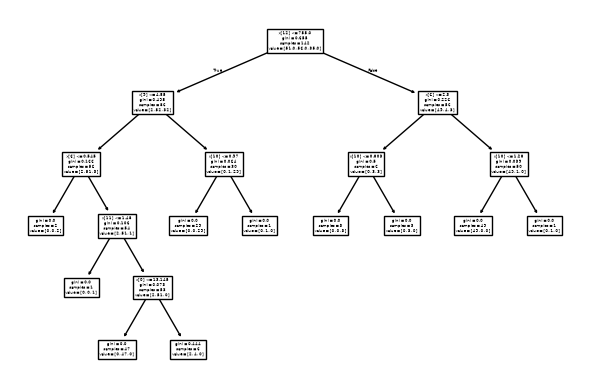

In [60]:
clf = DecisionTreeClassifier(max_depth = 5, random_state = 55)
clf.fit(X_train, Y_train)

predicted = clf.predict(X_test)
accuracy  = accuracy_score(Y_test, predicted)
precision = precision_score(Y_test, predicted, average='macro')
recall    = recall_score(Y_test, predicted,average='macro')
f1        = f1_score(Y_test, predicted, average='macro')

plt.figure(figsize=(6, 4))
plot_tree(clf)
plt.tight_layout()
plt.savefig('DT_max_depth_5.png')
plt.show()


depth = 5
accuracy_score :  0.9166666666666666
precision_score:  0.9326923076923078
recall_score   :  0.9104700854700855
f1_score       :  0.919878687620623


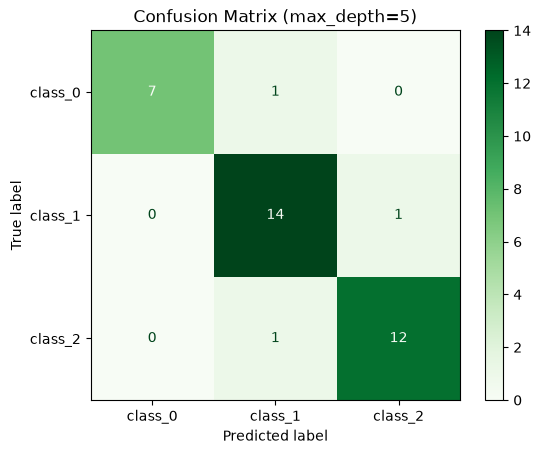

In [67]:
print("depth = 5")
print("accuracy_score : ",accuracy)
print("precision_score: ",precision)
print("recall_score   : ", recall)
print("f1_score       : ", f1)

cm = confusion_matrix(Y_test, predicted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data_wine.target_names)
disp.plot(cmap='Greens')
plt.title(f'Confusion Matrix (max_depth={5})')
plt.savefig('confusion_matrix.png')
plt.show()